<a href="https://colab.research.google.com/github/hiranshree/AIML/blob/main/weather_sensitivity_heatmap_code_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Processing 269 buildings...
Generating sensitivity heatmap for 269 buildings...
Saved: DGS_weather_sensitivity_heatmap.png


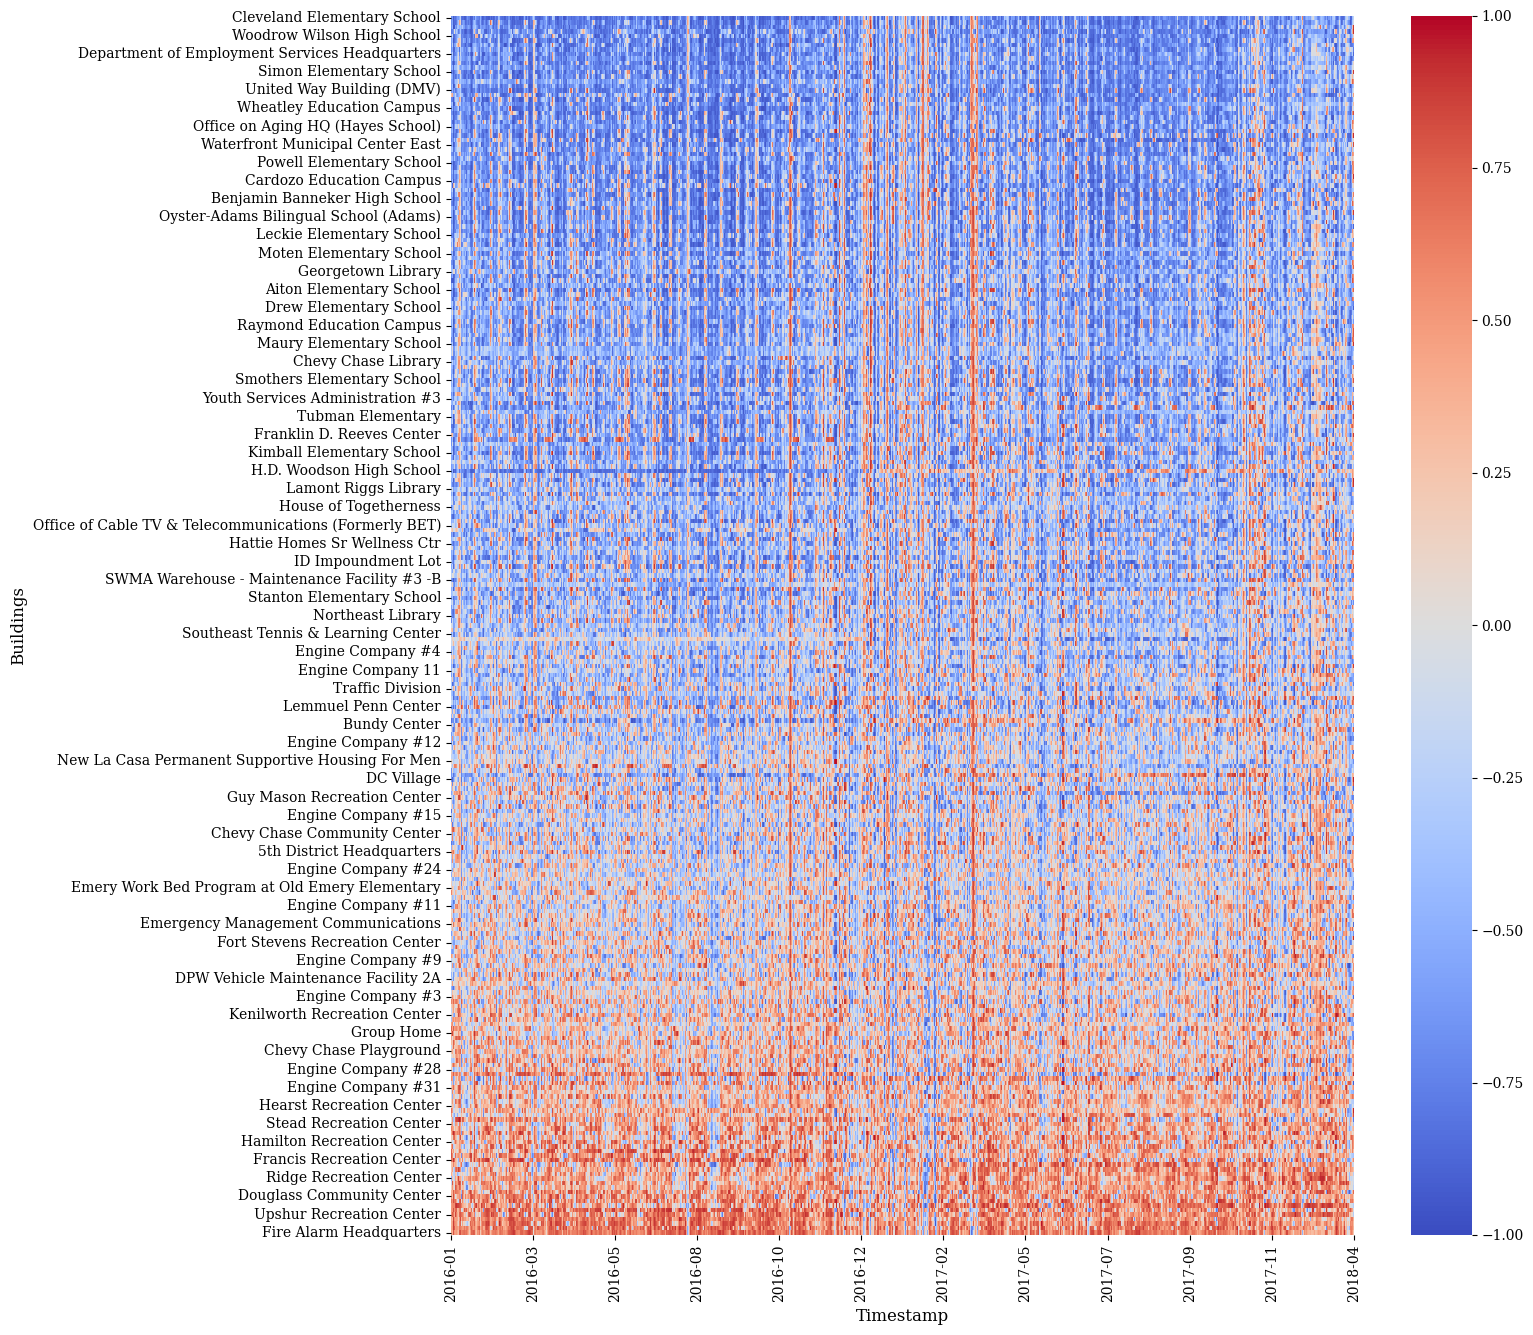

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def weather_sensitivity_all_buildings(electricity_file, weather_file, window_size=24):
    # --- 1. CONFIG ---
    plt.rcParams.update({"font.family": "serif", "axes.titlesize": 14})

    # --- 2. LOAD & CLEAN ---
    elec_df = pd.read_csv(electricity_file)
    weather_df = pd.read_csv(weather_file)

    e_time = next((c for c in elec_df.columns if c.lower() in ['timestamp', 'datetime', 'date']), 'Timestamp')
    w_time = next((c for c in weather_df.columns if c.lower() in ['timestamp', 'datetime', 'date']), 'Timestamp')

    # Fixed: Using 'h' instead of deprecated 'H'
    elec_df['Timestamp'] = pd.to_datetime(elec_df[e_time]).dt.round('h').dt.tz_localize(None)
    weather_df['Timestamp'] = pd.to_datetime(weather_df[w_time]).dt.round('h').dt.tz_localize(None)

    temp_col = next((c for c in weather_df.columns if 'temp' in c.lower() or 'value' in c.lower()), 'air_temperature')
    weather_subset = weather_df[['Timestamp', temp_col]].drop_duplicates('Timestamp').rename(columns={temp_col: 'temp'})

    # Merge
    df = pd.merge(elec_df, weather_subset, on='Timestamp', how='inner').sort_values('Timestamp').reset_index(drop=True)
    building_cols = [col for col in df.columns if col not in ['Timestamp', 'temp', e_time]]

    # --- 3. ROBUST CALCULATION ---
    print(f"Processing {len(building_cols)} buildings...")

    # Fill NaNs and add microscopic noise to prevent constant-value errors (std=0)
    data_clean = df[building_cols].fillna(0) + np.random.normal(0, 1e-9, (len(df), len(building_cols)))
    temp_clean = df['temp'].ffill().bfill() + np.random.normal(0, 1e-9, len(df))

    # Calculate Rolling Spearman (Rank-based Pearson)
    df_ranked = data_clean.rank()
    temp_ranked = temp_clean.rank()
    all_corrs = df_ranked.rolling(window=window_size, min_periods=window_size//2).corr(temp_ranked)

    # Clean output
    all_corrs = all_corrs.dropna(how='all')

    if all_corrs.empty:
        print("CRITICAL: Result is empty. Check if data length exceeds window size.")
        return

    # --- 4. ASCENDING CORRELATION SORT & DYNAMIC HEIGHT ---
    # Calculate mean correlation per building to determine the order
    # ascending=True: More negative (Heating) at top, More positive (Cooling) at bottom
    sorted_buildings = all_corrs.mean().sort_values(ascending=True).index

    # Reorder and Transpose
    plot_df = all_corrs[sorted_buildings].T

    # Dynamic Height Mechanism from Quality Script
    num_buildings = len(plot_df.index)
    dynamic_height = max(10, num_buildings * 0.05)
    dynamic_height = min(300, dynamic_height)

    # --- 5. VISUALIZATION ---
    print(f"Generating sensitivity heatmap for {num_buildings} buildings...")
    plt.figure(figsize=(16, dynamic_height))

    # rasterized=True is essential for 1100+ buildings to prevent memory/rendering lag
    ax = sns.heatmap(plot_df, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                     cbar_kws={'label': ''},
                     xticklabels=False, rasterized=True)

    plt.title("", fontsize=16, pad=20)
    plt.ylabel("Buildings", fontsize=12)
    plt.xlabel("Timestamp", fontsize=12)

    # Tick Logic
    num_time_steps = plot_df.shape[1]
    step_indices = np.linspace(0, num_time_steps - 1, 12).astype(int)
    ax.set_xticks(step_indices)

    # Map back to Timestamps using the indices of the correlation dataframe
    time_labels = df.loc[all_corrs.index[step_indices], 'Timestamp'].dt.strftime('%Y-%m')
    ax.set_xticklabels(time_labels, rotation=90)

    # --- 6. SAVE ---
    plt.tight_layout()
    save_path = 'DGS_weather_sensitivity_heatmap.png'
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()
    plt.close()

if __name__ == '__main__':
    elec_path = '/content/Electricity-hourly.csv'
    weather_path = '/content/Weather_Data.csv'
    weather_sensitivity_all_buildings(elec_path, weather_path)